# Library assistant

*  LangGraph states are immmutable, they return partial updates. So the state does not need to update every field in the state message, it can just return some updates.

* Reducers are good when the state is accumulating.

* The library state should have the following fields: 
    * section(borrow, return, overdue, unknown)
    * messages list with add reducer so we can keep the messages history
    * books borrowed list, we can then update the list delete items or add items as books are returned and new books are borrowed.
    * last_user_message this is optional because it will be used in routing
    * resolved state bool


In [48]:
from typing import TypedDict, Literal, Optional, Annotated, List
from langgraph.graph.message import add_messages
import operator

class LibraryAssistantState(TypedDict):
    section: Optional[Literal["borrow", "return", "overdue", "unknown"]]
    messages: Annotated[str, add_messages]
    books_borrowed: List[str]
    last_user_message: Optional[str]
    resolved: bool = False


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage

def handle_return(state: LibraryAssistantState) -> LibraryAssistantState:
    book_title = None
    for msg in reversed(state.get('messages', [])):  # Fixed: use .get() with default
        if isinstance(msg, HumanMessage):
            content = msg.content
            if 'return' in content.lower():
                # Extract book title after 'return'
                book_title = content.split('return', 1)[1].strip().title()
                break

    current_books = state.get('books_borrowed', [])

    if book_title and book_title in current_books:
        # Create a new list without the returned book (no direct mutation)
        updated_books = [book for book in current_books if book != book_title]
        ai_text = f"Thank you! I've removed '{book_title}' from your borrowed books."

        # Return the complete new list to replace the old one
        return {
            'messages': [AIMessage(content=ai_text)],
            'books_borrowed': updated_books,  # Replace entire list
            'resolved': True
        }
    elif book_title:
        ai_text = f"It doesn't look like you borrowed '{book_title}' from us."
    else:
        ai_text = "I'm sorry, I couldn't identify the book you're returning."

    return {
        'messages': [AIMessage(content=ai_text)],
        'resolved': True
    }

def handle_borrow(state: LibraryAssistantState) -> LibraryAssistantState:
    book_title = None
    for msg in reversed(state.get('messages', [])):
        if isinstance(msg, HumanMessage):
            content = msg.content
            if 'borrow' in content.lower():
                # Extract book title after 'borrow'
                book_title = content.split('borrow', 1)[1].strip().title()
                break

    current_books = state.get('books_borrowed', [])
    updates = {}

    if book_title:
        if book_title not in current_books:
            # Replace the entire list with updated version
            updates['books_borrowed'] = current_books + [book_title]
            ai_text = f"Sure! I've added '{book_title}' to your borrowed books."
        else:
            ai_text = f"It looks like '{book_title}' is already on your list."
    else:
        ai_text = "I'm sorry, I couldn't identify the book you'd like to borrow."

    return {
        'messages': [AIMessage(content=ai_text)],
        **updates,
        'resolved': True
    }

def handle_overdue(state: LibraryAssistantState) -> LibraryAssistantState:
    current_books = state.get('books_borrowed', [])

    if current_books:
        books_list = ', '.join([f"'{book}'" for book in current_books])
        ai_text = f"You currently have {len(current_books)} book(s) borrowed: {books_list}. Please visit the library to check if any fines apply."
    else:
        ai_text = "You have no books borrowed at the moment. There are no overdue fines."

    return {
        'messages': [AIMessage(content=ai_text)],
        'resolved': True
    }

def handle_unknown(state: LibraryAssistantState) -> LibraryAssistantState:
    return {'messages': [AIMessage(content="I'm sorry, I didn't understand your request. Could you please clarify? I can help you borrow books, return books, or check for overdue items.")],
            'resolved': True}

def router_library(state: LibraryAssistantState) -> LibraryAssistantState:
    last_msg = ''
    intent = 'unknown'

    for msg in reversed(state.get('messages', [])):
        if(isinstance(msg, HumanMessage)):
            last_msg = msg
            break
    if 'borrow' in last_msg.content.lower():
        intent = 'borrow'
    elif 'return' in last_msg.content.lower():
        intent = 'return'
    elif 'overdue' in last_msg.content.lower() or 'fine' in last_msg.content.lower():
        intent = 'overdue'

    return {'last_user_message': last_msg.content, 'resolved': False, 'section': intent}

## Create the graph and compile it


In [50]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# add all the nodes
workflow = StateGraph(LibraryAssistantState)
workflow.add_node("router", router_library)

def next_step(state: LibraryAssistantState):
    if state["resolved"]:
        return END
    return state["section"] or "router"

workflow.add_node("borrow", handle_borrow)
workflow.add_node("overdue", handle_overdue)
workflow.add_node("return", handle_return)
workflow.add_node("unknown", handle_unknown)


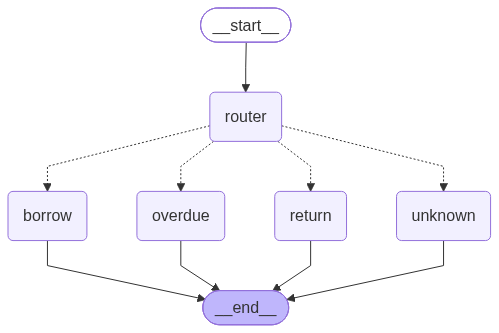

In [ ]:
workflow.set_entry_point("router")
workflow.add_conditional_edges('router', next_step, {
    'borrow': 'borrow',
    'return': 'return',
    'overdue': 'overdue',
    'unknown': 'unknown',
    END: END
})
workflow.add_edge("borrow", END)
workflow.add_edge("return", END)
workflow.add_edge("overdue", END)
workflow.add_edge("unknown", END)

memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)

from IPython.display import Image, display
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)